# SOCIAL MEDIA, SCREEN TIME AND MENTAL HEALTH 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("social_media_screentime_mental_health_2026.csv")

In [3]:
df.head()
# frist 5 rows

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [4]:
df.tail()
# last 5 rows

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
6995,P306995,30,Male,Part-time employed,Europe,Snapchat,4,3.6,74,Never,...,4,4,6,3,10,2,Yes,No,No,Good
6996,P306996,28,Male,Self-employed,North America,Facebook,3,5.0,104,Every night,...,8,1,7,6,7,1,No,"Yes, failed",No,Moderate
6997,P306997,26,Prefer not to say,Unemployed,Oceania,LinkedIn,3,1.2,25,Never,...,9,4,5,1,6,3,No,No,No,Good
6998,P306998,22,Female,Student,Europe,Snapchat,4,3.6,182,Sometimes,...,5,7,4,1,6,2,No,"Yes, failed",No,Good
6999,P306999,29,Male,Student,Asia,Facebook,1,5.8,14,Every night,...,5,7,4,9,6,3,No,No,Considering it,Moderate


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       7000 non-null   str    
 1   age                                  7000 non-null   int64  
 2   gender                               6930 non-null   str    
 3   occupation                           7000 non-null   str    
 4   region                               7000 non-null   str    
 5   most_used_platform                   7000 non-null   str    
 6   platforms_used_count                 7000 non-null   int64  
 7   daily_screen_hours                   7000 non-null   float64
 8   daily_notifications                  7000 non-null   int64  
 9   night_time_use                       7000 non-null   str    
 10  minutes_to_first_check_after_waking  7000 non-null   int64  
 11  primary_purpose                      7000

The dataset consists of 7,000 rows and 25 columns. Only two variables contain missing values: gender and avg_sleep_hours.

In [6]:
# check if partecipant_id is unique: are there duplicates?
df['participant_id'].duplicated().sum()

# NO.

np.int64(0)

ABOUT SOME VARIABLES

In [7]:
bins = [12, 20, 30, 40, 50, 100]
labels = ['Teen','Young','Adult','Middle-aged adult','Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [8]:
order = ['Good', 'Moderate', 'At-risk']
df["wellbeing_band"] = pd.Categorical(df["wellbeing_band"], categories = order, ordered = True)

## MISSING VALUES

In [9]:
df.isna().sum()

participant_id                           0
age                                      0
gender                                  70
occupation                               0
region                                   0
most_used_platform                       0
platforms_used_count                     0
daily_screen_hours                       0
daily_notifications                      0
night_time_use                           0
minutes_to_first_check_after_waking      0
primary_purpose                          0
avg_sleep_hours                        105
anxiety_score_0to27                      0
low_mood_score_0to27                     0
life_satisfaction_1to10                  0
loneliness_1to10                         0
self_esteem_1to10                        0
fomo_1to10                               0
social_comparison_1to10                  0
physical_activity_days_per_week          0
uses_screen_time_limits                  0
attempted_digital_detox                  0
seeks_menta

In [10]:
(df.isna().mean()*100).sort_values()
# low percentage of missing: 1% for gender, 1.5% for avg_sleep_hours

participant_id                         0.0
age                                    0.0
occupation                             0.0
region                                 0.0
platforms_used_count                   0.0
most_used_platform                     0.0
daily_screen_hours                     0.0
daily_notifications                    0.0
anxiety_score_0to27                    0.0
night_time_use                         0.0
minutes_to_first_check_after_waking    0.0
primary_purpose                        0.0
life_satisfaction_1to10                0.0
low_mood_score_0to27                   0.0
self_esteem_1to10                      0.0
loneliness_1to10                       0.0
wellbeing_band                         0.0
age_group                              0.0
fomo_1to10                             0.0
social_comparison_1to10                0.0
physical_activity_days_per_week        0.0
uses_screen_time_limits                0.0
attempted_digital_detox                0.0
seeks_menta

In [11]:
df[df["gender"].isna()]

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band,age_group
99,P300099,29,NaN,Retired,Latin America,Reddit,4,1.7,40,Sometimes,...,3,7,4,5,2,Yes,No,No,Moderate,Young
118,P300118,32,NaN,Self-employed,North America,Reddit,4,3.4,169,Never,...,3,5,3,7,1,No,No,No,Moderate,Adult
180,P300180,35,NaN,Self-employed,Asia,X/Twitter,5,4.4,86,Often,...,3,2,4,4,1,No,No,Yes,Moderate,Adult
185,P300185,28,NaN,Student,Asia,Facebook,8,1.9,38,Often,...,7,9,2,1,1,No,No,No,Moderate,Young
353,P300353,34,NaN,Student,North America,Reddit,1,5.4,27,Sometimes,...,5,7,5,6,5,No,"Yes, failed",No,Moderate,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6560,P306560,26,NaN,Student,North America,Instagram,1,5.1,61,Never,...,5,9,3,6,3,No,No,Considering it,Moderate,Young
6629,P306629,34,NaN,Full-time employed,North America,TikTok,4,4.2,124,Sometimes,...,3,5,2,9,3,No,No,Yes,Moderate,Adult
6633,P306633,32,NaN,Unemployed,Europe,Reddit,2,1.5,51,Often,...,2,6,1,7,1,Yes,"Yes, failed",No,Moderate,Adult
6717,P306717,21,NaN,Unemployed,North America,TikTok,2,3.9,103,Every night,...,5,8,3,6,2,Yes,"Yes, succeeded",No,At-risk,Young


In [12]:
df[df["avg_sleep_hours"].isna()]

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band,age_group
22,P300022,28,Female,Student,Asia,TikTok,4,3.0,11,Sometimes,...,2,9,3,6,2,Yes,No,No,Moderate,Young
48,P300048,17,Female,Full-time employed,North America,Snapchat,2,1.5,18,Sometimes,...,2,8,7,2,2,Yes,"Yes, failed",Considering it,Good,Teen
53,P300053,36,Female,Self-employed,Latin America,TikTok,2,2.1,35,Every night,...,3,8,1,3,3,No,"Yes, succeeded",No,Good,Adult
60,P300060,21,Male,Retired,North America,TikTok,4,1.2,18,Every night,...,6,8,4,5,2,Yes,No,No,Moderate,Young
91,P300091,36,Male,Self-employed,Africa,TikTok,1,1.8,31,Often,...,5,8,2,2,3,No,No,Yes,Moderate,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6723,P306723,37,Male,Full-time employed,North America,Facebook,5,2.5,21,Sometimes,...,7,6,6,5,2,Yes,"Yes, succeeded",Yes,Good,Adult
6758,P306758,27,Male,Full-time employed,North America,Instagram,4,3.2,41,Often,...,5,6,8,8,1,No,No,Yes,Good,Young
6869,P306869,34,Prefer not to say,Student,Latin America,Instagram,1,4.2,9,Sometimes,...,8,7,6,7,3,No,No,No,Moderate,Adult
6887,P306887,42,Male,Student,North America,Reddit,5,5.1,152,Sometimes,...,7,6,9,10,2,Yes,No,No,Moderate,Middle-aged adult


In [13]:
df["avg_sleep_hours"].describe()

count    6895.000000
mean        6.964989
std         0.870575
min         3.800000
25%         6.400000
50%         7.000000
75%         7.600000
max        10.000000
Name: avg_sleep_hours, dtype: float64

<Axes: >

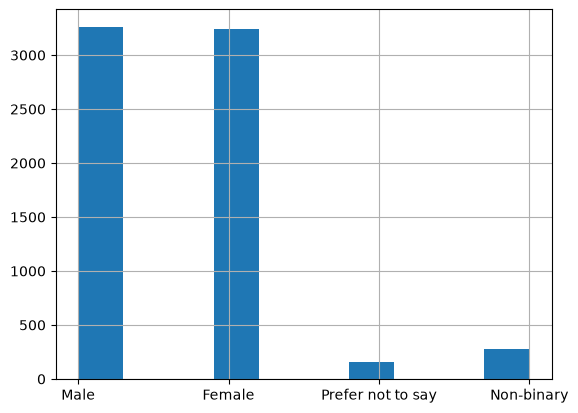

In [14]:
df["gender"].hist()

In [15]:
df["gender"].value_counts()

gender
Male                 3261
Female               3240
Non-binary            276
Prefer not to say     153
Name: count, dtype: int64

Nature of missing values
- MCAR (Missing Completely At Random) → completely missing values
- MAR (Missing At Random) → depend on other variables
- MNAR (Missing Not At Random) → depend on missing value

In [16]:
df["gender_missing"] = df["gender"].isna()

In [17]:
df.groupby(df["gender_missing"])["age"].describe()

,count,mean,std,min,25%,50%,75%,max
gender_missing,,,,,,,,
False,6930.0,29.250072,9.573361,13.0,22.00,29.0,36.00,71.0
True,70.0,28.900000,9.200110,13.0,22.25,29.0,34.75,57.0


In [18]:
df.groupby(df["gender_missing"])["daily_screen_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
gender_missing,,,,,,,,
False,6930.0,3.305815,1.882597,0.2,1.900,3.00,4.30,14.0
True,70.0,3.221429,1.764209,0.7,1.925,2.85,4.05,8.3


In [19]:
df.groupby("gender_missing").mean(numeric_only=True).T

gender_missing,False,True
age,29.250072,28.900000
platforms_used_count,3.495382,3.414286
daily_screen_hours,3.305815,3.221429
daily_notifications,61.552092,59.171429
minutes_to_first_check_after_waking,20.038817,16.985714
avg_sleep_hours,6.964523,7.011765
anxiety_score_0to27,11.375469,11.628571
low_mood_score_0to27,3.851515,3.271429
life_satisfaction_1to10,6.955267,7.014286
loneliness_1to10,4.684127,4.200000


The missing values in gender do not appear to be associated with observable characteristics such as age or daily screen time. The similar distributions between missing and non-missing groups suggest that the missing mechanism may be consistent with MCAR; however, further checks involving additional numerical and categorical variables are required.

In [20]:
df["sleep_missing"] = df["avg_sleep_hours"].isna()

In [21]:
df.groupby("sleep_missing").mean(numeric_only=True).T

sleep_missing,False,True
age,29.227556,30.495238
platforms_used_count,3.494416,3.504762
daily_screen_hours,3.309471,3.009524
daily_notifications,61.719942,48.942857
minutes_to_first_check_after_waking,19.992313,21.057143
avg_sleep_hours,6.964989,NaN
anxiety_score_0to27,11.386367,10.828571
low_mood_score_0to27,3.844815,3.904762
life_satisfaction_1to10,6.955910,6.952381
loneliness_1to10,4.683394,4.409524


In [22]:
df.columns

Index(['participant_id', 'age', 'gender', 'occupation', 'region',
       'most_used_platform', 'platforms_used_count', 'daily_screen_hours',
       'daily_notifications', 'night_time_use',
       'minutes_to_first_check_after_waking', 'primary_purpose',
       'avg_sleep_hours', 'anxiety_score_0to27', 'low_mood_score_0to27',
       'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10',
       'fomo_1to10', 'social_comparison_1to10',
       'physical_activity_days_per_week', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band', 'age_group', 'gender_missing', 'sleep_missing'],
      dtype='str')

We can drop missing values, because there aren't patterns and the percentage of missing is very low.

In [23]:
df_clean = df.dropna()

In [24]:
df_clean.shape

(6827, 28)

Ckeck range and cardinality

In [25]:
df_clean.describe()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
count,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000,6827.000000
mean,29.230409,3.494947,3.310078,61.735902,20.022411,6.964523,11.383477,3.851472,6.955764,4.688736,6.002637,4.641131,5.326791,2.806650
std,9.576428,1.760681,1.884573,54.995025,13.972796,0.871917,4.777929,3.539476,1.616310,2.093184,1.887006,2.158690,2.091586,1.287592
min,13.000000,1.000000,0.200000,5.000000,0.000000,3.800000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,22.000000,2.000000,1.900000,24.000000,10.000000,6.400000,8.000000,0.000000,6.000000,3.000000,5.000000,3.000000,4.000000,2.000000
50%,29.000000,3.000000,3.000000,46.000000,17.000000,7.000000,11.000000,3.000000,7.000000,5.000000,6.000000,5.000000,5.000000,3.000000
75%,36.000000,5.000000,4.300000,83.000000,27.000000,7.600000,14.000000,6.000000,8.000000,6.000000,7.000000,6.000000,7.000000,4.000000
max,71.000000,8.000000,14.000000,400.000000,111.000000,10.000000,27.000000,19.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000


The dataset contains 6,827 observations after the treatment of missing values. The descriptive statistics show that the sample is mainly composed of young individuals, with an average age of approximately 29 years (SD = 9.6), ranging from 13 to 71 years. The median age is also 29 years, indicating a relatively balanced age distribution.

Regarding digital behavior, participants use an average of 3.5 social media platforms, with values ranging from 1 to 8 platforms. The average daily screen time is approximately 3.3 hours, although the high standard deviation (1.9 hours) suggests substantial variability among individuals. Similarly, the number of daily notifications shows considerable dispersion, with an average of around 62 notifications per day and values reaching up to 400.

The average time spent before checking the phone after waking up is approximately 20 minutes, with considerable variation across individuals. Sleep duration appears relatively stable, with participants reporting an average of about 7 hours of sleep per night and a limited variability (SD = 0.87).

Psychological and well-being indicators show intermediate average values. The mean anxiety score is 11.4 out of 27, while the low mood score has an average value of 3.9 out of 27. Life satisfaction is relatively positive, with an average score of approximately 7 out of 10. Self-esteem also presents an average value of 6 out of 10, while loneliness, FOMO, and social comparison scores are centered around the middle of their respective scales.

Finally, participants report engaging in physical activity for approximately 2.8 days per week on average, with values ranging from no weekly activity to daily activity. Overall, the descriptive statistics indicate a heterogeneous sample in terms of digital habits, while psychological and lifestyle variables appear to cover a broad range of individual experiences.

In [26]:
# CHECK CATEGORICAL VARIABLES IN ORDER TO APPLY POSSIBLE TRANSFORMATION
cat_cols = df_clean.select_dtypes(exclude='number').columns.tolist()

cat_cols.remove('participant_id')
cat_cols.remove('gender_missing')
cat_cols.remove('sleep_missing')

print(cat_cols)

['gender', 'occupation', 'region', 'most_used_platform', 'night_time_use', 'primary_purpose', 'uses_screen_time_limits', 'attempted_digital_detox', 'seeks_mental_health_support', 'wellbeing_band', 'age_group']


In [27]:
for col in cat_cols:
    print("="*50)
    summary = pd.DataFrame({
        "count": df_clean[col].value_counts(),
        "percentage": (
            df_clean[col].value_counts(normalize=True).mul(100).round(2))})
    print(summary)

                   count  percentage
gender                              
Male                3211       47.03
Female              3195       46.80
Non-binary           271        3.97
Prefer not to say    150        2.20
                    count  percentage
occupation                           
Student              2637       38.63
Full-time employed   2234       32.72
Part-time employed    702       10.28
Self-employed         519        7.60
Unemployed            514        7.53
Retired               221        3.24
               count  percentage
region                          
Asia            1916       28.07
Europe          1791       26.23
North America   1791       26.23
Latin America    651        9.54
Africa           412        6.03
Oceania          266        3.90
                    count  percentage
most_used_platform                   
TikTok               1691       24.77
Instagram            1660       24.32
YouTube              1237       18.12
X/Twitter           

Some conclusions:
the dataset is mainly composed of students of both genders, located in Asia, Europe and North America. Tiktok and Instagram are the most used platforms (24.77%, 24.32%) especially for entertainment. Most people use social media at night, without any restrictions; half haven't considered a possible detox, and 33.85% have failed. 20% are thinking about pursuing mental support, and the mental health of a good portion of the observations fluctuates between good and at risk.

In [28]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 6827 entries, 0 to 6999
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   participant_id                       6827 non-null   str     
 1   age                                  6827 non-null   int64   
 2   gender                               6827 non-null   str     
 3   occupation                           6827 non-null   str     
 4   region                               6827 non-null   str     
 5   most_used_platform                   6827 non-null   str     
 6   platforms_used_count                 6827 non-null   int64   
 7   daily_screen_hours                   6827 non-null   float64 
 8   daily_notifications                  6827 non-null   int64   
 9   night_time_use                       6827 non-null   str     
 10  minutes_to_first_check_after_waking  6827 non-null   int64   
 11  primary_purpose                  

# EDA

# UNIVARIATE ANALYSIS

NUMERICAL VARIABLES DISTRIBUTION

In [29]:
num = df_clean.select_dtypes(include='number')

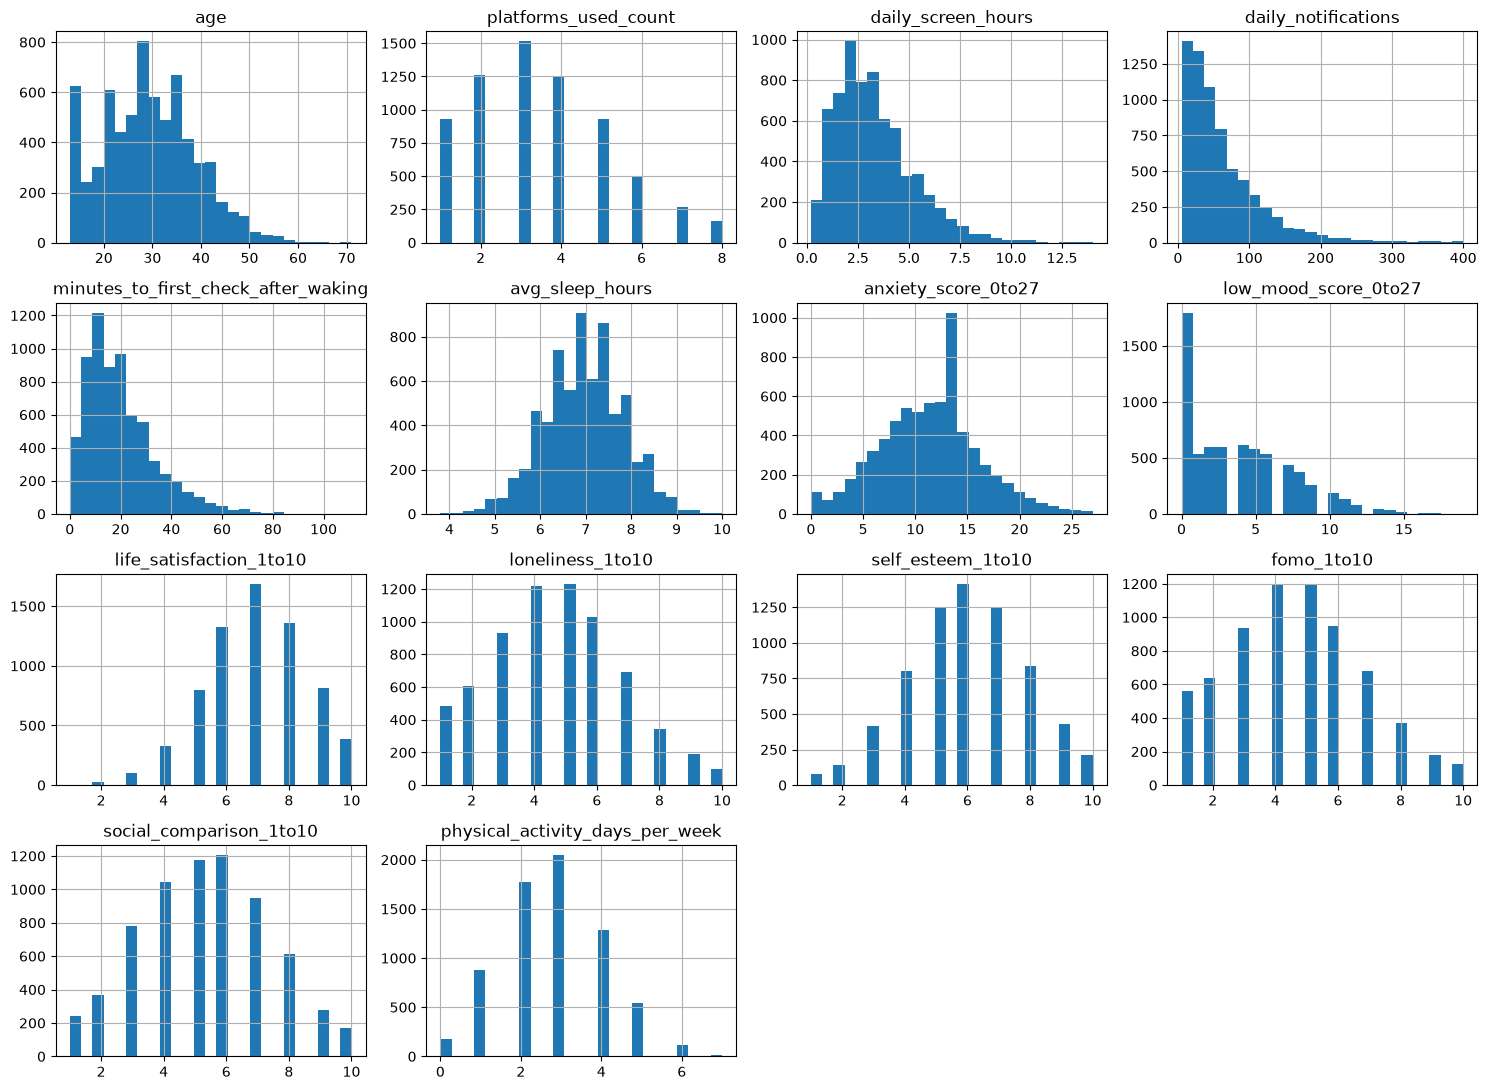

In [30]:
num.hist(figsize=(15, 11), bins=25)
plt.tight_layout()
plt.show()

# con le variabili numeriche, la distribuzione la studio e analizzo attraverso gli istogrammi

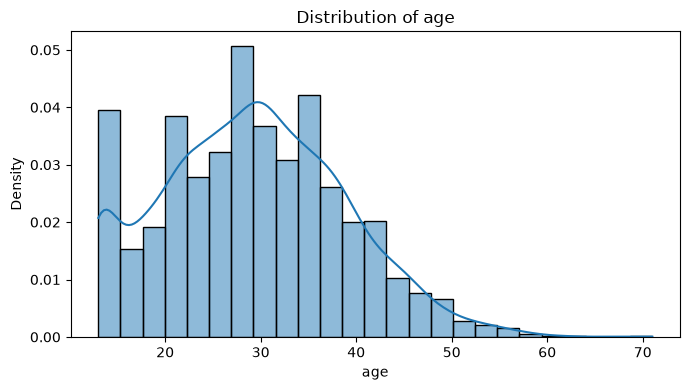

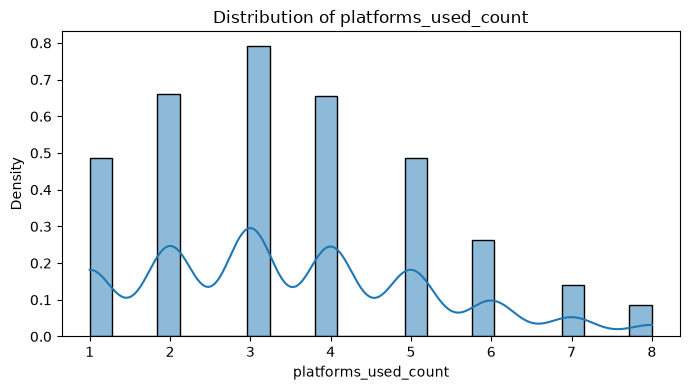

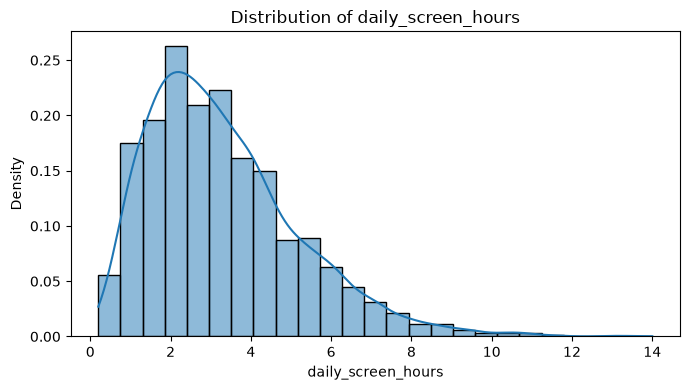

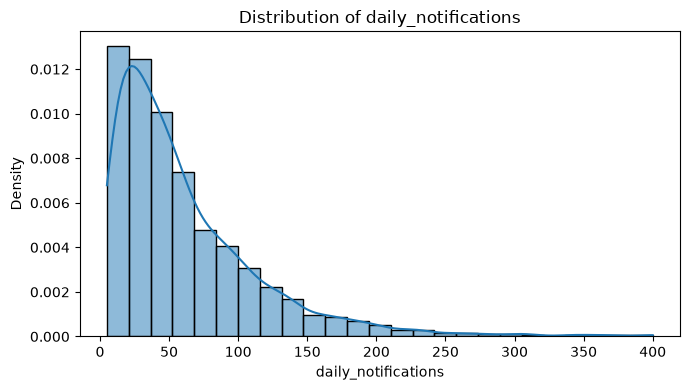

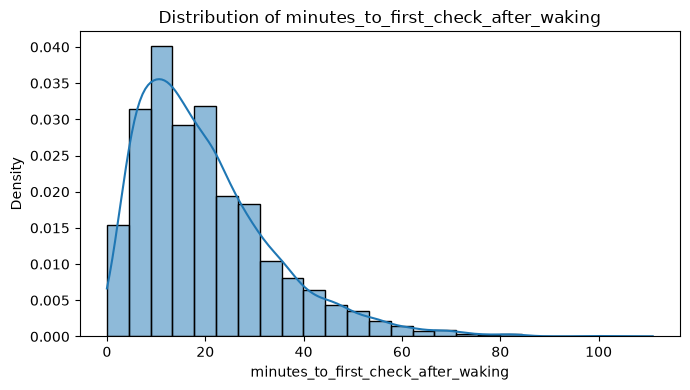

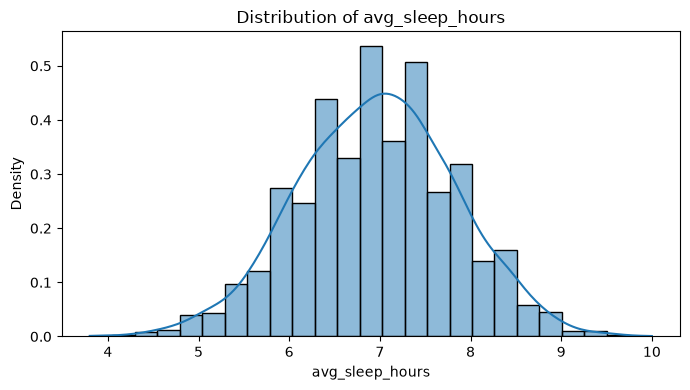

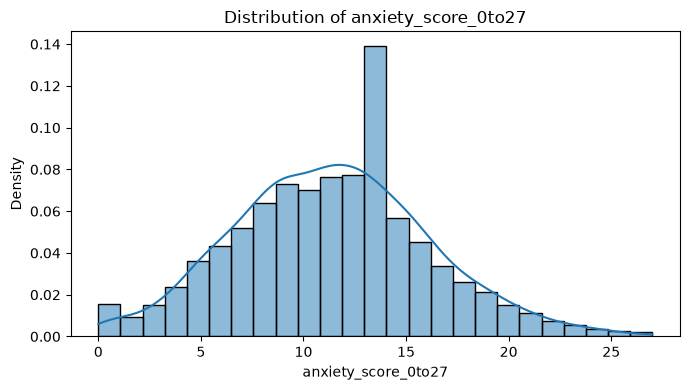

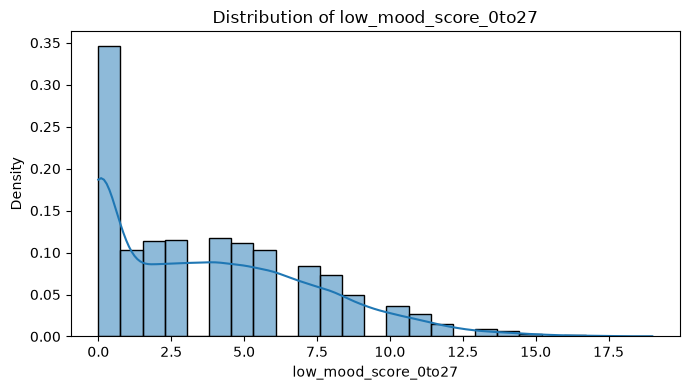

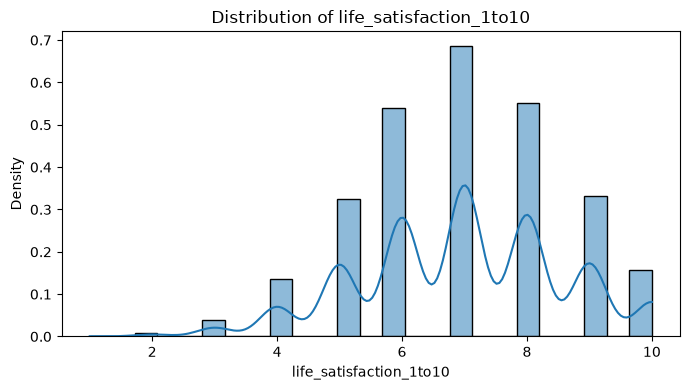

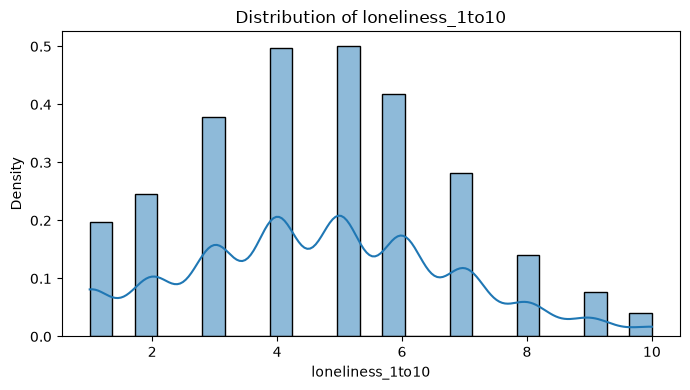

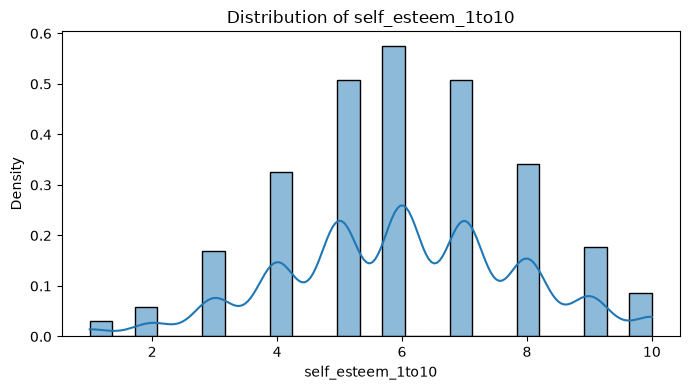

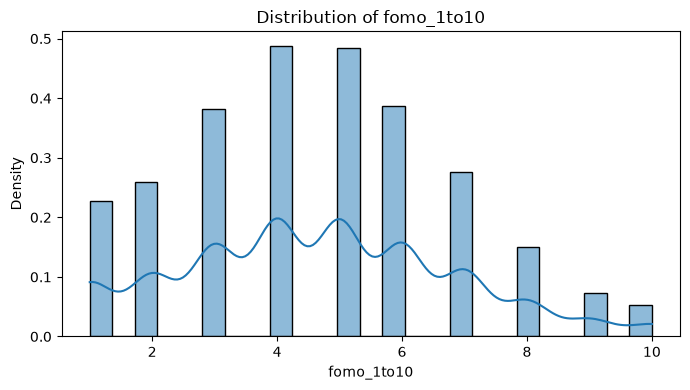

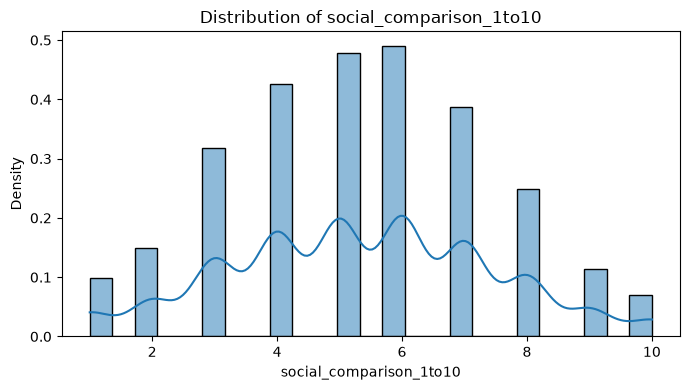

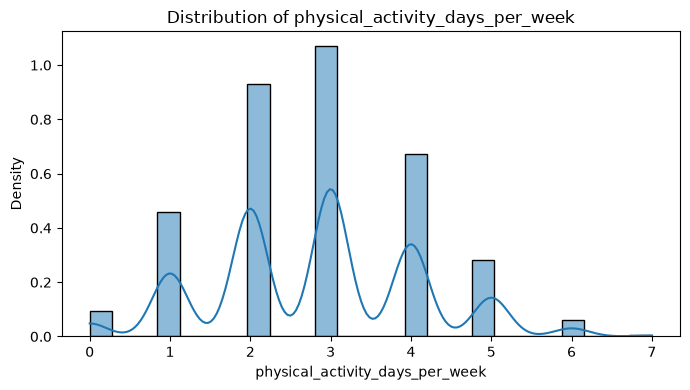

In [31]:
for col in num:
    plt.figure(figsize=(7, 4))
    sns.histplot(data = num, x = col, bins = 25, kde = True, stat = "density")

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

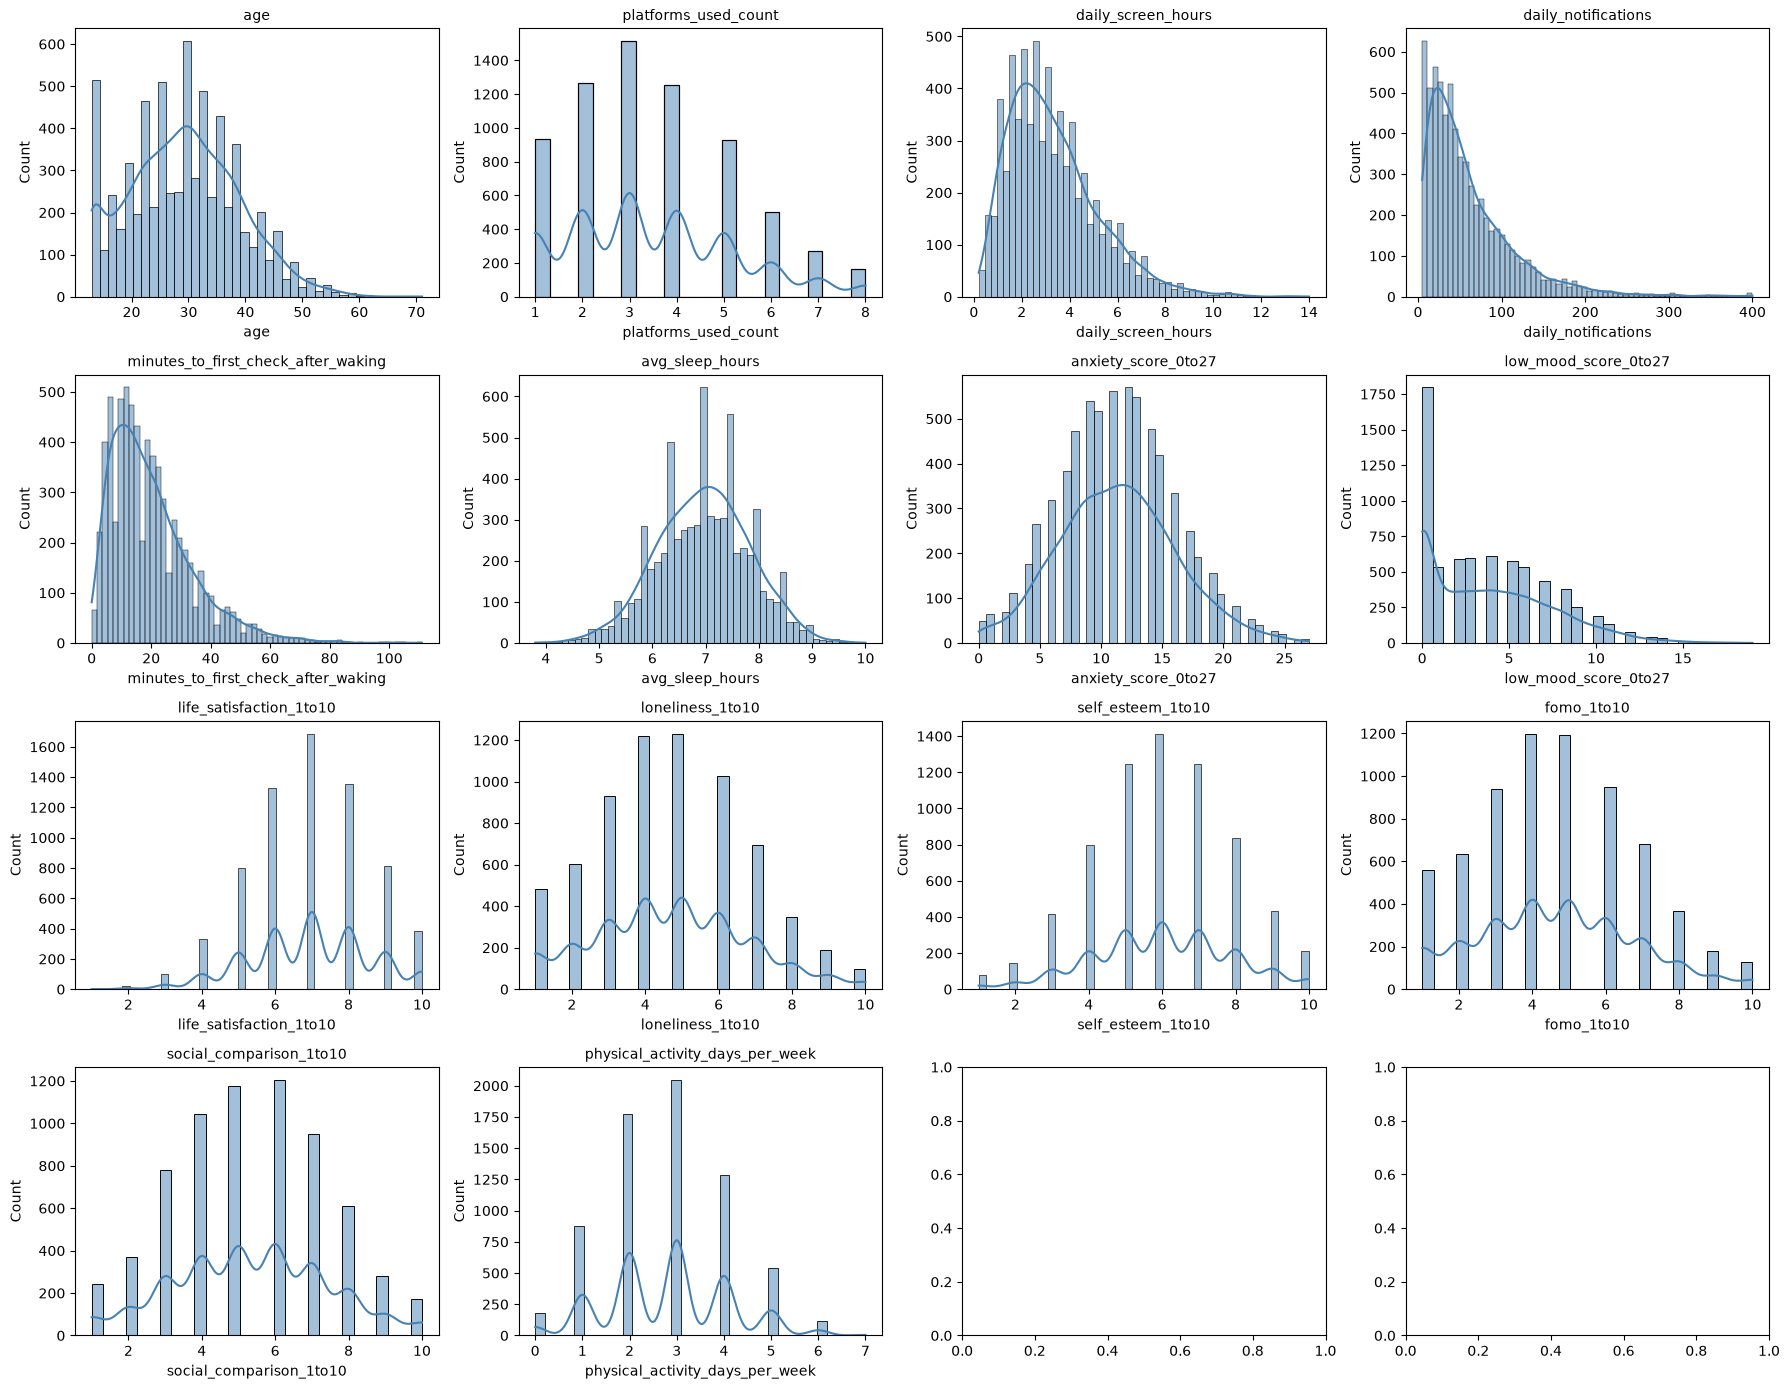

In [32]:
# con aiuto AI
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, num):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)

for ax in axes[len(num):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

CATEGORICAL VARIABLES DISTRIBUTION

In [33]:
# categorical variables distribution -> countplot
cat = df_clean.select_dtypes(exclude='number')
cat = cat.drop(columns=['participant_id'])

cat = cat.drop(columns=['gender_missing','sleep_missing'])
cat.columns

Index(['gender', 'occupation', 'region', 'most_used_platform',
       'night_time_use', 'primary_purpose', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band', 'age_group'],
      dtype='str')

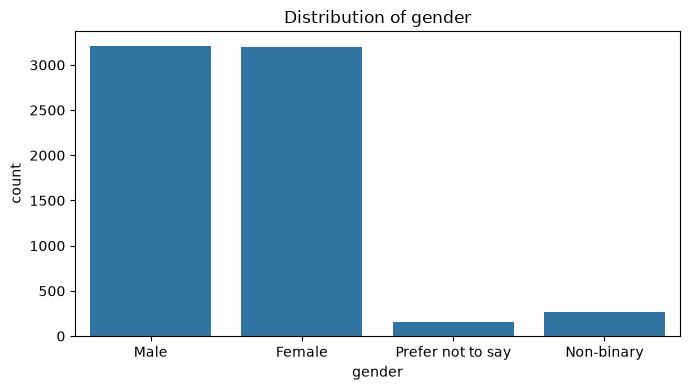

In [34]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean,x='gender')

plt.title('Distribution of gender')
plt.tight_layout()
plt.show()

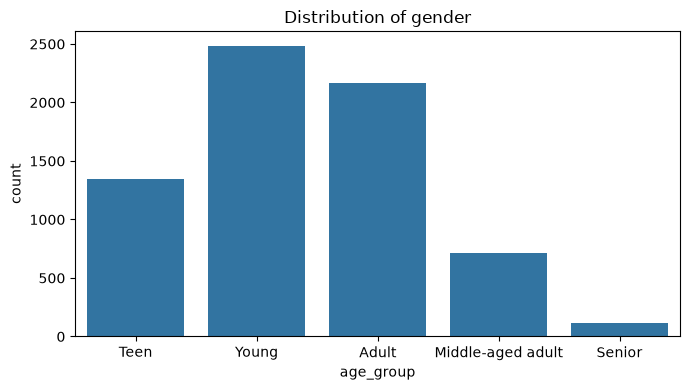

In [35]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean,x='age_group')

plt.title('Distribution of gender')
plt.tight_layout()
plt.show()

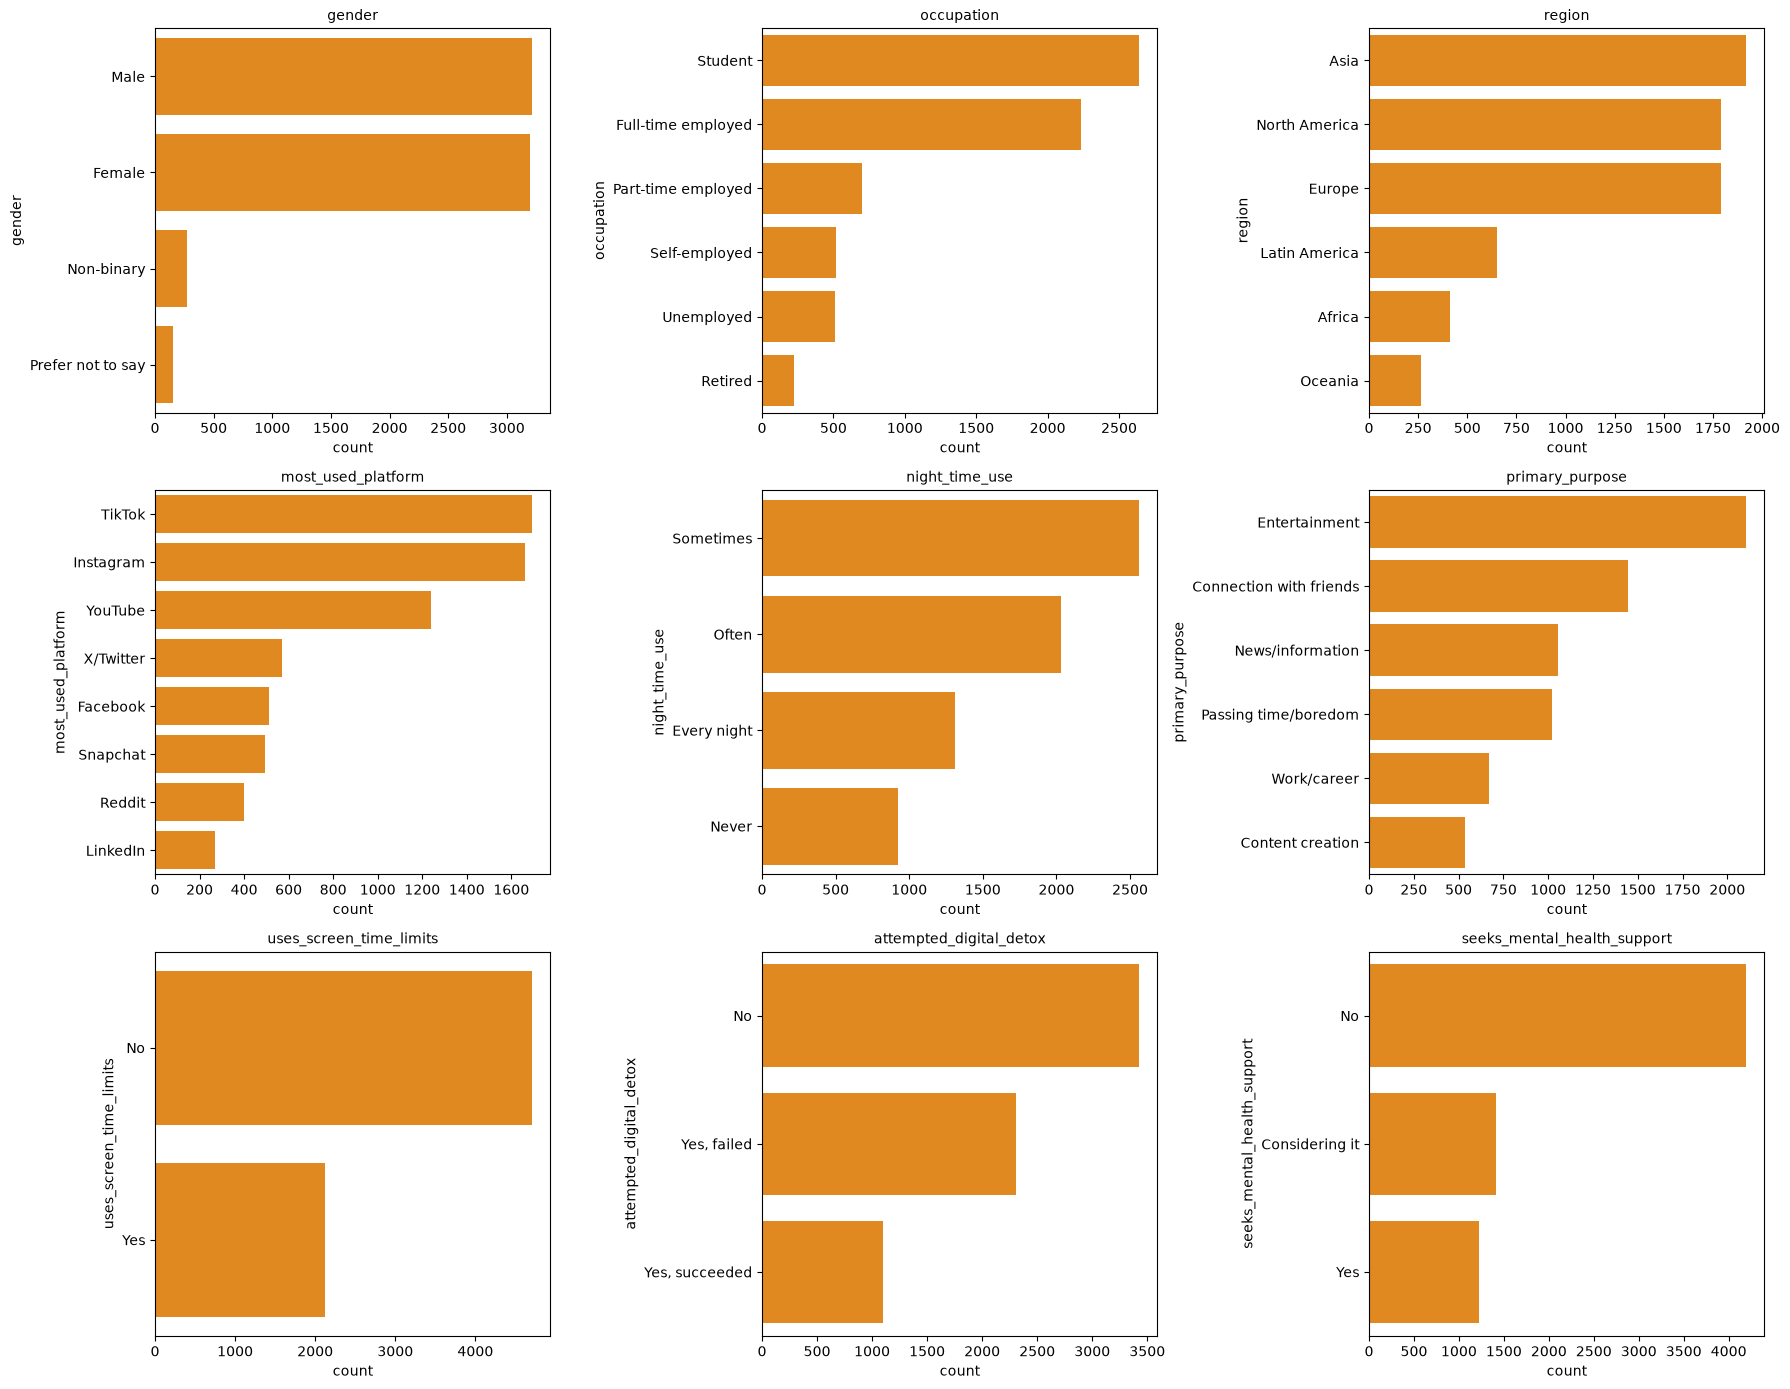

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat):
    order = df[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=ax, color="darkorange")
    ax.set_title(col, fontsize=10)

for ax in axes[len(cat):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [37]:
corr = num.corr()
corr

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
age,1.000000,0.016643,0.006988,0.014359,-0.016594,0.003002,-0.004752,-0.006887,0.011505,-0.012668,-0.013094,0.005070,-0.006385,-0.014267
platforms_used_count,0.016643,1.000000,-0.014802,-0.010478,-0.005965,0.007880,-0.002155,-0.004563,-0.012794,-0.145617,0.011645,-0.015086,-0.009039,-0.013808
daily_screen_hours,0.006988,-0.014802,1.000000,0.605423,0.009192,-0.382168,0.526774,-0.357931,-0.364233,0.342654,-0.295588,0.431086,0.351211,0.003103
daily_notifications,0.014359,-0.010478,0.605423,1.000000,-0.022836,-0.237595,0.324303,-0.221500,-0.220917,0.211362,-0.183728,0.254688,0.202033,-0.003115
minutes_to_first_check_after_waking,-0.016594,-0.005965,0.009192,-0.022836,1.000000,-0.002073,0.011109,-0.010588,-0.001493,0.016948,-0.020932,-0.013712,-0.010186,0.004557
avg_sleep_hours,0.003002,0.007880,-0.382168,-0.237595,-0.002073,1.000000,-0.257016,0.187508,0.268154,-0.133463,0.124740,-0.167118,-0.134470,0.003011
anxiety_score_0to27,-0.004752,-0.002155,0.526774,0.324303,0.011109,-0.257016,1.000000,-0.206443,-0.220151,0.179982,-0.151697,0.236543,0.175657,-0.005211
low_mood_score_0to27,-0.006887,-0.004563,-0.357931,-0.221500,-0.010588,0.187508,-0.206443,1.000000,0.134213,-0.127058,0.111199,-0.157509,-0.126740,0.007134
life_satisfaction_1to10,0.011505,-0.012794,-0.364233,-0.220917,-0.001493,0.268154,-0.220151,0.134213,1.000000,-0.138002,0.102107,-0.161877,-0.143884,0.002859
loneliness_1to10,-0.012668,-0.145617,0.342654,0.211362,0.016948,-0.133463,0.179982,-0.127058,-0.138002,1.000000,-0.113212,0.150742,0.113852,0.022782


# BIVARIATE ANALYSIS

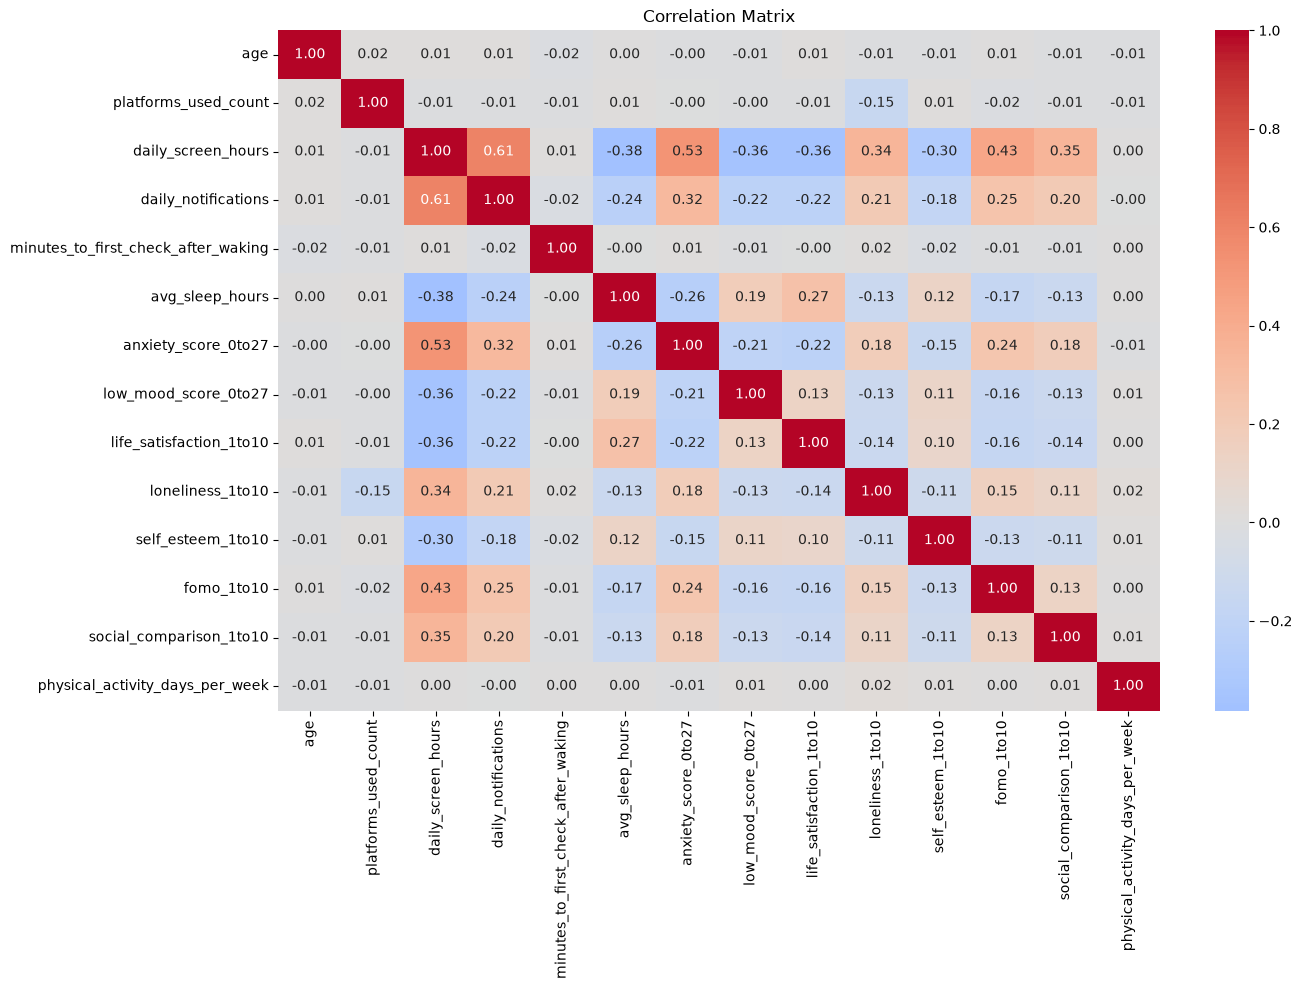

In [38]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Most correlated variables: 
- daily notifications - daily screen hours 0.61
- daily screen hours - anxiety score 1to27 0.53
- daily screen hours - fomo 1to10          0.43
- daily screen hours - avg_sleep_hours    -0.38 

# BOXPLOT

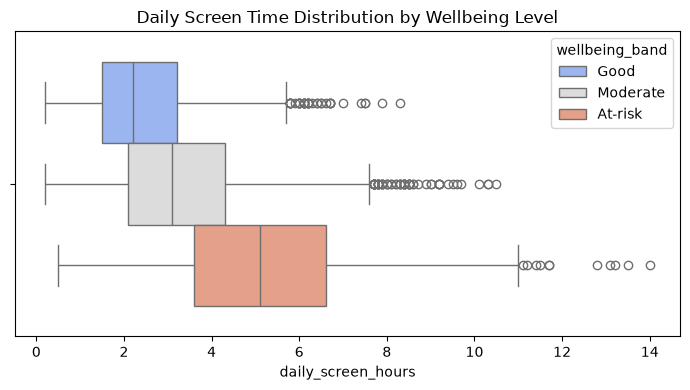

In [39]:
plt.figure(figsize=(7,4))
sns.boxplot(x="daily_screen_hours", hue="wellbeing_band",data=df_clean, palette = "coolwarm", legend = True)
plt.title("Daily Screen Time Distribution by Wellbeing Level")
plt.tight_layout()
plt.show()

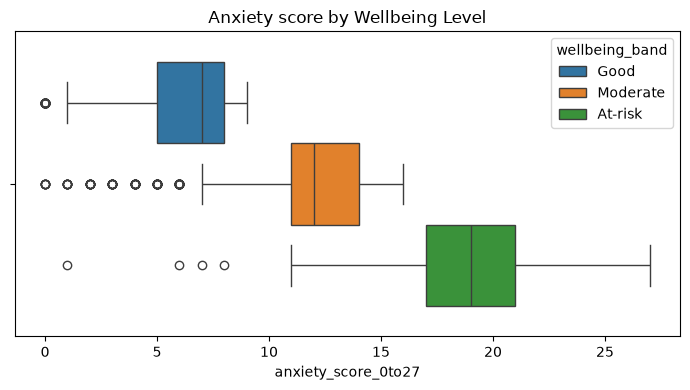

In [40]:
plt.figure(figsize=(7,4))
sns.boxplot(x="anxiety_score_0to27", hue="wellbeing_band",data=df_clean, legend = True)
plt.title("Anxiety score by Wellbeing Level")
plt.tight_layout()
plt.show()

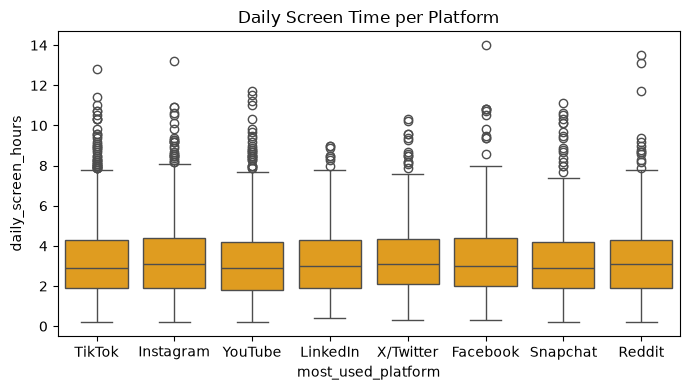

In [41]:
plt.figure(figsize=(7,4))
sns.boxplot(x="most_used_platform", y="daily_screen_hours",data=df_clean, color = "orange")
plt.title("Daily Screen Time per Platform")
plt.tight_layout()
plt.show()

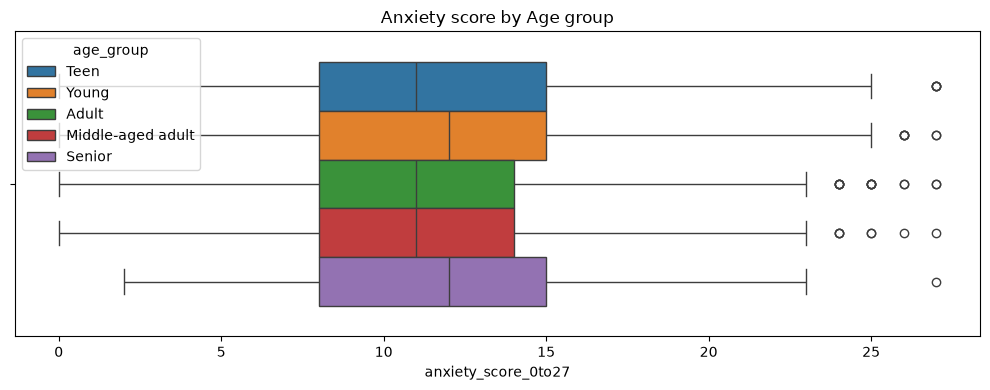

In [42]:
plt.figure(figsize=(10,4))
sns.boxplot(x="anxiety_score_0to27", hue="age_group",data=df_clean, legend = True)
plt.title("Anxiety score by Age group")
plt.tight_layout()
plt.show()

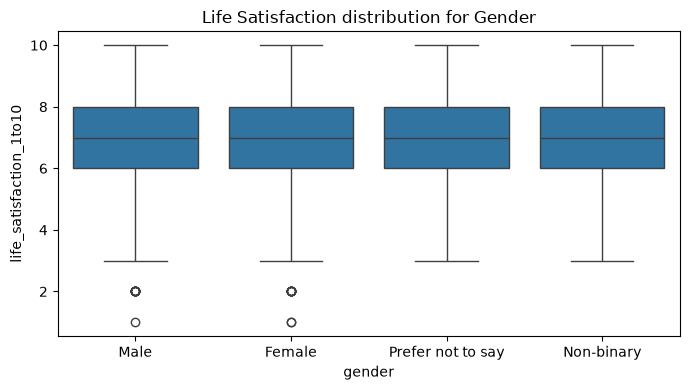

In [43]:
plt.figure(figsize=(7,4))
sns.boxplot(x='gender',y='life_satisfaction_1to10',data=df_clean)
plt.title("Life Satisfaction distribution for Gender")
plt.tight_layout()
plt.show()

# SCATTER PLOT

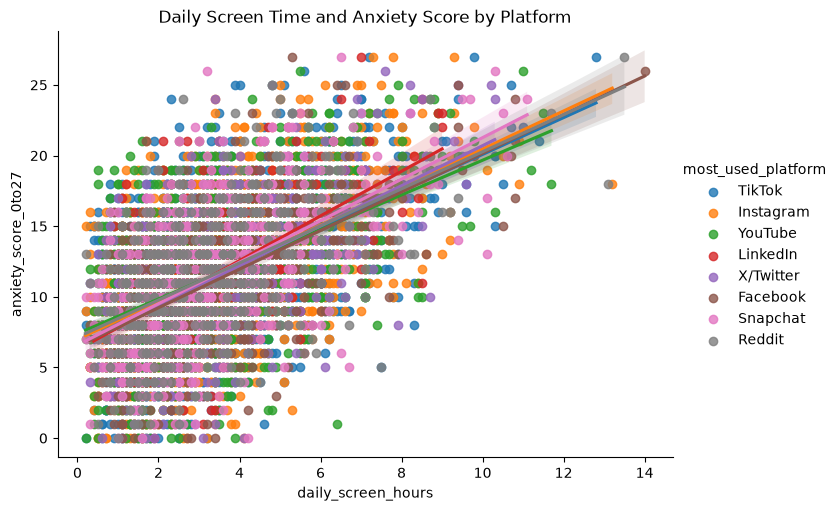

In [44]:
sns.lmplot(
    x="daily_screen_hours",
    y="anxiety_score_0to27",
    data=df_clean,
    hue="most_used_platform",
    height=5,
    aspect=1.4)

plt.title("Daily Screen Time and Anxiety Score by Platform")
plt.show()

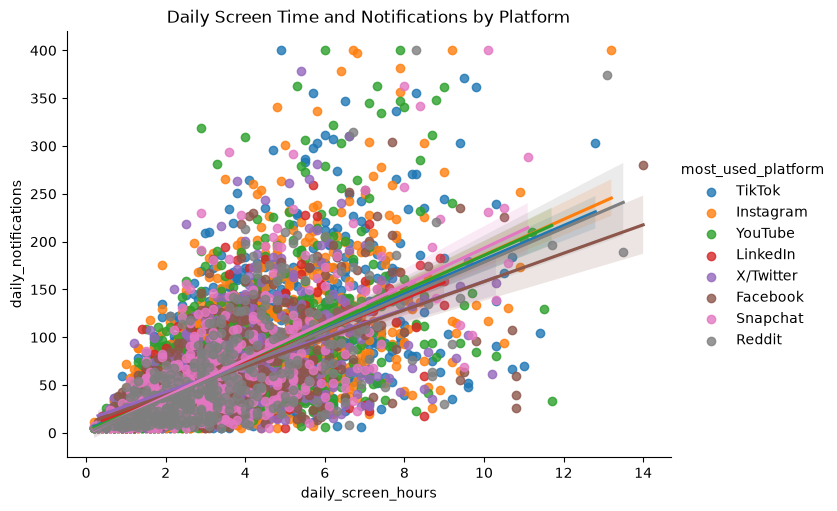

In [45]:
sns.lmplot(
    x="daily_screen_hours",
    y="daily_notifications",
    data=df_clean,
    hue="most_used_platform",
    height=5,
    aspect=1.4
)

plt.title("Daily Screen Time and Notifications by Platform")
plt.show()

In [46]:
df_final = df.drop(columns=['gender_missing', 'sleep_missing'])
df_final.to_csv('updated_dataset.csv', index=False)

# MACHINE LEARNING MODELS

## La storia in 3 tappe: quanto pesa il leakage?

Invece di allenare solo il modello "onesto", confrontiamo tre scenari con le **stesse 4 modelli** (Logistic Regression, SVC, Random Forest, XGBoost):

1. **Full (con leakage)** — tutte le feature, inclusi i punteggi psicologici (`anxiety_score_0to27`, `low_mood_score_0to27`, `life_satisfaction_1to10`, `loneliness_1to10`, `self_esteem_1to10`, `seeks_mental_health_support`).
2. **Onesto** — escludiamo quei punteggi, teniamo solo comportamento digitale + demografia + sonno + attività fisica (incluse `fomo_1to10` e `social_comparison_1to10`, borderline).
3. **Stretto** — come Onesto, ma escludiamo anche `fomo_1to10` e `social_comparison_1to10`, per vedere se contribuivano in modo sospetto.

Se il macro-F1 crolla da Full a Onesto, confermiamo empiricamente il leakage. Se crolla poco (o niente) anche da Onesto a Stretto, vuol dire che fomo/social comparison non erano una fonte di leakage residuo — possiamo tenerle.

In [ ]:
LEAKAGE_COLS = [
    'anxiety_score_0to27', 'low_mood_score_0to27', 'life_satisfaction_1to10',
    'loneliness_1to10', 'self_esteem_1to10', 'seeks_mental_health_support'
]
BORDERLINE_COLS = ['fomo_1to10', 'social_comparison_1to10']

DROP_ALWAYS = ['participant_id', 'age_group']
TARGET = 'wellbeing_band'

ALL_NUMERIC = [
    'age', 'platforms_used_count', 'daily_screen_hours', 'daily_notifications',
    'minutes_to_first_check_after_waking', 'avg_sleep_hours',
    'anxiety_score_0to27', 'low_mood_score_0to27', 'life_satisfaction_1to10',
    'loneliness_1to10', 'self_esteem_1to10', 'fomo_1to10', 'social_comparison_1to10',
    'physical_activity_days_per_week'
]
ALL_CATEGORICAL = [
    'gender', 'occupation', 'region', 'most_used_platform', 'night_time_use',
    'primary_purpose', 'uses_screen_time_limits', 'attempted_digital_detox',
    'seeks_mental_health_support'
]

STAGES = {
    'Full (con leakage)': [],
    'Onesto': LEAKAGE_COLS,
    'Stretto (senza fomo/social)': LEAKAGE_COLS + BORDERLINE_COLS
}

# Sanity check: ogni colonna di df_final (tranne target/drop) deve rientrare in numeric o categorical
check_cols = set(df_final.columns) - set(DROP_ALWAYS) - {TARGET}
assert check_cols == set(ALL_NUMERIC) | set(ALL_CATEGORICAL), "Colonne non assegnate: controlla le liste sopra"


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np

# Target encoder condiviso: stesse categorie/ordine per tutti gli stage, fit una sola volta sui dati completi
target_encoder = OrdinalEncoder(categories=[['Good', 'Moderate', 'At-risk']])
target_encoder.fit(df_final[TARGET].astype(str).to_numpy().reshape(-1, 1))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def build_preprocessor(feature_cols):
    numeric_features = [c for c in ALL_NUMERIC if c in feature_cols]
    categorical_features = [c for c in ALL_CATEGORICAL if c in feature_cols]
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


def make_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'SVC': SVC(class_weight='balanced', probability=True, random_state=42),
        'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
        'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
    }


def evaluate_stage(stage_name, exclude_cols):
    feature_cols = [c for c in df_final.columns if c not in DROP_ALWAYS + [TARGET] + exclude_cols]
    X = df_final[feature_cols]
    y = df_final[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    y_train_enc = target_encoder.transform(y_train.astype(str).to_numpy().reshape(-1, 1)).ravel()
    y_test_enc = target_encoder.transform(y_test.astype(str).to_numpy().reshape(-1, 1)).ravel()

    preprocessor = build_preprocessor(feature_cols)
    pipelines = {
        name: Pipeline([('preprocessor', preprocessor), ('model', model)])
        for name, model in make_models().items()
    }

    rows, fitted = [], {}
    for name, pipe in pipelines.items():
        if name == 'XGBoost':
            sw = compute_sample_weight(class_weight='balanced', y=y_train_enc)
            cv_scores = cross_val_score(
                pipe, X_train, y_train_enc, cv=cv, scoring='f1_macro',
                params={'model__sample_weight': sw}
            )
            pipe.fit(X_train, y_train_enc, model__sample_weight=sw)
        else:
            cv_scores = cross_val_score(pipe, X_train, y_train_enc, cv=cv, scoring='f1_macro')
            pipe.fit(X_train, y_train_enc)

        y_pred = pipe.predict(X_test)
        test_f1 = f1_score(y_test_enc, y_pred, average='macro')

        rows.append({
            'stage': stage_name, 'model': name,
            'cv_f1_mean': cv_scores.mean(), 'cv_f1_std': cv_scores.std(),
            'test_f1_macro': test_f1
        })
        fitted[name] = pipe

    return pd.DataFrame(rows), fitted, (X_test, y_test_enc)


In [ ]:
all_results = []
stage_artifacts = {}

for stage_name, exclude_cols in STAGES.items():
    print(f"Training stage: {stage_name}...")
    res_df, fitted, test_data = evaluate_stage(stage_name, exclude_cols)
    all_results.append(res_df)
    stage_artifacts[stage_name] = {'fitted': fitted, 'test_data': test_data}

results_df = pd.concat(all_results, ignore_index=True)
results_df.sort_values(['model', 'stage'])


In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='model', y='test_f1_macro', hue='stage')
plt.title('Macro-F1 sul test set: Full vs Onesto vs Stretto')
plt.ylabel('Macro-F1 (test)')
plt.ylim(0, 1)
plt.legend(title='', loc='lower right')
plt.tight_layout()
plt.show()


**Come leggere il grafico:**
- Se le barre "Full" sono nettamente più alte delle altre due, confermiamo che i punteggi psicologici permettevano al modello di "copiare" il target invece di imparare un pattern comportamentale reale.
- Se "Onesto" e "Stretto" sono simili, `fomo_1to10` e `social_comparison_1to10` non erano una fonte di leakage — possiamo tenerle come feature legittime nel modello finale.
- Il modello **Onesto** (o Stretto, se si rivela meglio) è quello che riportiamo come risultato principale: è l'unico che risponde davvero alla domanda "il comportamento digitale predice il benessere?".

## Prova del leakage: feature importance nel modello "Full"

Se il leakage esiste, ce lo aspettiamo visibile qui: i punteggi psicologici dovrebbero dominare nettamente l'importanza delle feature nel Random Forest allenato con tutte le variabili.

In [ ]:
full_pipe = stage_artifacts['Full (con leakage)']['fitted']['Random Forest']
feature_names = full_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = full_pipe.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False) \
    .head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', color='steelblue')
plt.title('Top 15 feature importance — Random Forest (Full, con leakage)')
plt.tight_layout()
plt.show()


## Valutazione dettagliata del modello onesto

Classification report e matrici di confusione per lo stage **Onesto**, quello che useremo come risultato principale.

In [ ]:
onesto_fitted = stage_artifacts['Onesto']['fitted']
X_test_onesto, y_test_onesto = stage_artifacts['Onesto']['test_data']

fig, axes = plt.subplots(1, len(onesto_fitted), figsize=(20, 5))

for ax, (name, pipe) in zip(axes, onesto_fitted.items()):
    y_pred = pipe.predict(X_test_onesto)

    print("=" * 60)
    print(name)
    print(classification_report(y_test_onesto, y_pred, target_names=['Good', 'Moderate', 'At-risk']))

    cm = confusion_matrix(y_test_onesto, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Good', 'Moderate', 'At-risk']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Sintesi della storia

- **Full → Onesto**: il calo di macro-F1 misura quanto i punteggi psicologici "regalavano" la risposta al modello.
- **Onesto → Stretto**: verifica se `fomo`/`social_comparison` erano anch'esse leakage mascherato.
- Il modello onesto, anche con performance più basse del Full, è l'unico risultato **utilizzabile** per rispondere alla domanda reale del progetto: quali comportamenti digitali sono associati al benessere.

### Prossimi passi
- Feature importance / SHAP sul modello onesto migliore (non sul Full) per interpretare i comportamenti più rilevanti.
- Tuning degli iperparametri (GridSearchCV/RandomizedSearchCV) sul modello onesto vincente, dentro la CV.
- Eventualmente ripetere l'analisi con `life_satisfaction_1to10` come target di regressione, sempre escludendo gli altri punteggi psicologici dalle feature.